In [1]:
import tensorflow as tf

In [2]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.5
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

In [3]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3
#from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob

In [9]:
gpus=tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f"GPU")
else:
    print("no")



GPU


In [10]:
IMAGE_SIZE = [224, 224]

train_path = r'D:\priya\Plant_dataset_extracted\train'
valid_path = r'D:\priya\Plant_dataset_extracted\test'

In [11]:
inception = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [12]:

for layer in inception.layers:
    layer.trainable = False

In [13]:
from glob import glob

folders = []

folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\aloevera'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\banana'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\bilimbi'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\cantaloupe'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\cassava'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\coconut'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\corn'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\cucumber'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\curcuma'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\eggplant'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\galangal'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\ginger'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\guava'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\kale'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\longbeans'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\mango'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\melon'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\orange'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\paddy'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\papaya'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\peperchili'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\pineapple'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\pomelo'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\shallot'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\soybeans'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\spinach'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\sweetpotatoes'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\tobacco'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\waterapple'))
folders.extend(glob(r'D:\priya\Plant_dataset_extracted\train\watermelon'))





In [14]:
len(folders)

30

In [15]:
x = Flatten()(inception.output)

In [16]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=inception.input, outputs=prediction)

In [17]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 111, 111, 32  864         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_94 (BatchN  (None, 111, 111, 32  96         ['conv2d_94[0][0]']              
 ormalization)                  )                                                             

In [18]:
optimizer = tf.keras.optimizers.SGD()
model.compile(
  loss='categorical_crossentropy',
  optimizer=optimizer,
  metrics=['accuracy']
)

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [20]:
training_set = train_datagen.flow_from_directory(r'D:\priya\Plant_dataset_extracted\train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 21000 images belonging to 30 classes.


In [21]:
test_set = test_datagen.flow_from_directory(r'D:\priya\Plant_dataset_extracted\test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 6000 images belonging to 30 classes.


In [63]:
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=50,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set),
)

Epoch 1/50
657/657 [==============================] - 261s 397ms/step - loss: 1.0765 - accuracy: 0.8794 - val_loss: 2.1919 - val_accuracy: 0.8030
Epoch 2/50
657/657 [==============================] - 255s 388ms/step - loss: 1.0386 - accuracy: 0.8826 - val_loss: 1.9185 - val_accuracy: 0.8107
Epoch 3/50
657/657 [==============================] - 254s 387ms/step - loss: 1.0017 - accuracy: 0.8899 - val_loss: 2.3053 - val_accuracy: 0.7905
Epoch 4/50
657/657 [==============================] - 255s 387ms/step - loss: 0.9555 - accuracy: 0.8914 - val_loss: 2.3663 - val_accuracy: 0.7832
Epoch 5/50
657/657 [==============================] - 254s 387ms/step - loss: 0.9997 - accuracy: 0.8918 - val_loss: 2.4344 - val_accuracy: 0.8052
Epoch 6/50
657/657 [==============================] - 254s 386ms/step - loss: 0.8974 - accuracy: 0.9052 - val_loss: 1.9667 - val_accuracy: 0.8088
Epoch 7/50
657/657 [==============================] - 255s 387ms/step - loss: 0.8530 - accuracy: 0.9064 - val_loss: 2.7286 -

In [65]:
model.save('Plant.h5')

In [66]:
!pip install matplotlib 

In [67]:
import matplotlib.pyplot as plt

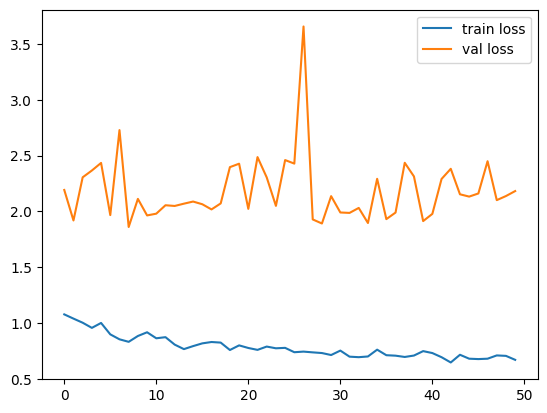

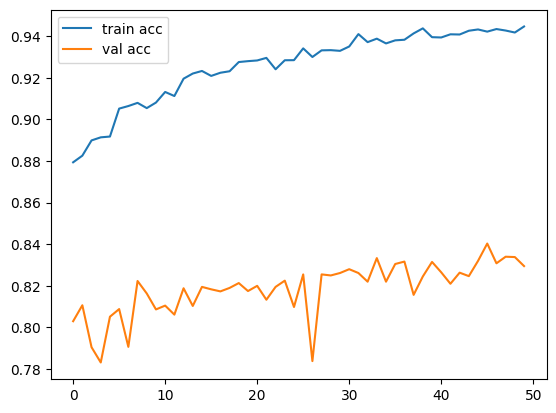

<Figure size 640x480 with 0 Axes>

In [68]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [69]:
from tensorflow.keras.models import load_model

model.save('Plant.h5')

In [70]:
y_pred = model.predict(test_set)

188/188 [==============================] - 17s 83ms/step


In [71]:
y_pred

array([[1.0000000e+00, 1.6385389e-15, 5.5898875e-14, ..., 2.5514753e-16,
        4.8125480e-25, 5.6839922e-11],
       [8.8221039e-32, 1.0662618e-31, 7.0168909e-19, ..., 5.8511870e-28,
        7.6016927e-28, 0.0000000e+00],
       [5.4058432e-07, 8.3968368e-14, 4.0233671e-16, ..., 8.9783129e-15,
        2.9531310e-15, 5.3507063e-18],
       ...,
       [2.8663989e-08, 1.1860843e-24, 3.0441119e-29, ..., 3.2354365e-15,
        1.2948988e-26, 1.5538503e-28],
       [5.8540551e-17, 8.1091287e-16, 1.2190633e-21, ..., 4.5207972e-18,
        8.4983365e-21, 2.2475156e-31],
       [9.4700766e-21, 6.0021864e-07, 5.9558532e-14, ..., 4.2108925e-20,
        9.8496340e-17, 6.3136989e-15]], dtype=float32)

In [72]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)

In [73]:
y_pred

array([ 0, 22, 13, ..., 21, 14,  9], dtype=int64)

In [74]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [75]:
model=load_model('Plant.h5')

In [76]:
img=image.load_img(r'D:\priya\Plant_dataset_extracted\train\aloevera\aloevera1.jpg',target_size=(224,224))

In [77]:
x=image.img_to_array(img)
x

array([[[102., 171., 117.],
        [103., 172., 115.],
        [ 89., 159.,  97.],
        ...,
        [ 54., 132.,  56.],
        [125., 196., 126.],
        [168., 237., 170.]],

       [[ 51., 117.,  71.],
        [ 61., 127.,  79.],
        [ 60., 129.,  75.],
        ...,
        [106., 184., 109.],
        [184., 255., 184.],
        [125., 196., 126.]],

       [[ 76., 131., 100.],
        [ 39.,  96.,  63.],
        [ 41., 101.,  65.],
        ...,
        [138., 218., 149.],
        [144., 222., 146.],
        [ 69., 145.,  70.]],

       ...,

       [[ 95., 143.,  57.],
        [ 94., 142.,  58.],
        [148., 195., 114.],
        ...,
        [254., 244., 182.],
        [251., 253., 190.],
        [243., 247., 186.]],

       [[125., 170.,  85.],
        [113., 158.,  75.],
        [144., 189., 108.],
        ...,
        [255., 233., 172.],
        [232., 236., 160.],
        [220., 231., 152.]],

       [[207., 249., 165.],
        [209., 251., 169.],
        [193., 2

In [78]:
x.shape

(224, 224, 3)

In [79]:
x=x/255

In [80]:
import numpy as np
x=np.expand_dims(x,axis=0)
img_data=preprocess_input(x)
img_data.shape

(1, 224, 224, 3)

In [81]:
model.predict(img_data)

1/1 [==============================] - 1s 915ms/step


array([[3.8956462e-03, 3.0569055e-03, 6.8150263e-04, 1.7394722e-04,
        3.8709852e-05, 2.4081723e-07, 3.1325929e-03, 4.8939783e-06,
        2.4067743e-03, 2.3951150e-05, 8.5213463e-07, 1.0447046e-02,
        5.4974567e-05, 1.0258963e-01, 6.4373060e-05, 2.8359473e-06,
        2.5423840e-04, 9.7459906e-06, 2.6416648e-04, 6.0354928e-06,
        5.8309297e-04, 3.5939042e-06, 1.3538351e-05, 6.1584979e-07,
        3.7313145e-04, 2.7852191e-02, 6.7286502e-04, 8.4338456e-01,
        7.3053152e-06, 3.5813936e-09]], dtype=float32)

In [82]:
a=np.argmax(model.predict(img_data), axis=1)

1/1 [==============================] - 0s 29ms/step


In [83]:
def predict_class(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    # Normalize the image
    img_array /= 255.

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)

    # Assuming classes are ordered as per their indices
    class_labels = ['aloevera', 'banana','bilimbi','cantoloupe','cassava', 'coconut','corn','cucumber','curcuma','eggplant','galangal','ginger','guava','kale','longbeans', 'mango','melon','orange','paddy','papaya','peperchili','pineapple','pomelo','shallot','soybeans','spinach','sweetpotatoes','tobacco','waterapple','watermelon']
    return class_labels[predicted_class]


In [85]:
image_path = r'D:\priya\Plant_dataset_extracted\train\paddy\paddy17.jpg'
predicted_class = predict_class(image_path)
print("Predicted class:", predicted_class)

1/1 [==============================] - 0s 9ms/step
Predicted class: paddy
